# VAR Generator

Generate multivariate time series using Vector Autoregression (VAR) models.
VAR models capture linear interdependencies among multiple time series, where each variable
depends on its own lagged values and the lagged values of all other variables.

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import VARGenerator

## 1. VAR(1) with Auto-Generated Stable Coefficients

Generate a 3-variable VAR(1) model with automatically generated stable coefficient matrices.

In [ ]:
params_auto = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "lag_order": 1,
    "seed": 42,
}

gen_auto = VARGenerator(engine="polars", **params_auto)
df_auto = gen_auto.generate(n_series=3)

print(f"Generated {len(df_auto)} observations for 3 variables")
df_auto.head(10)

Generated 600 observations for 3 variables


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,2.057667
"""0""",2000-01-02 00:00:00,0.295293
"""0""",2000-01-03 00:00:00,0.893053
"""0""",2000-01-04 00:00:00,0.235888
"""0""",2000-01-05 00:00:00,1.876363
"""0""",2000-01-06 00:00:00,-0.051986
"""0""",2000-01-07 00:00:00,1.583556
"""0""",2000-01-08 00:00:00,-1.001584
"""0""",2000-01-09 00:00:00,-0.94835


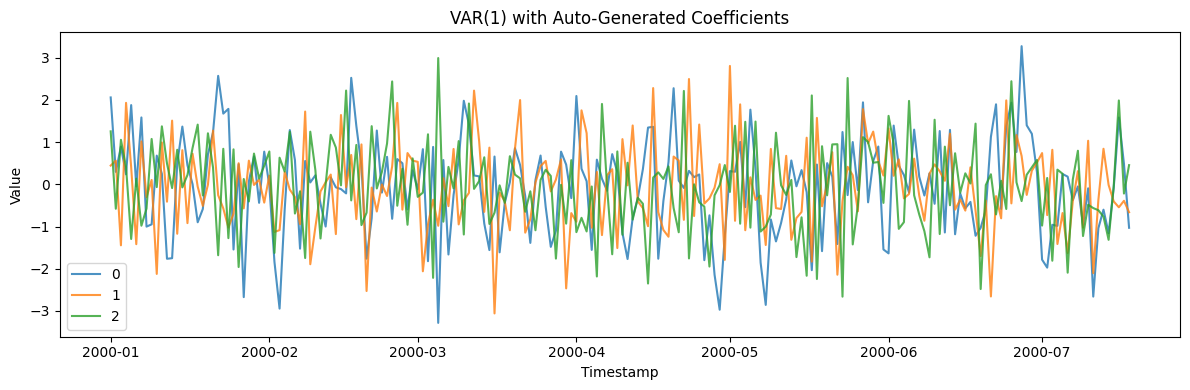

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_auto["unique_id"].unique().to_list():
    series = df_auto.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("VAR(1) with Auto-Generated Coefficients")
ax.legend()
plt.tight_layout()
plt.show()

### Summary Statistics and Correlations

In [ ]:
stats = df_auto.group_by("unique_id").agg(
    pl.col("y").mean().alias("mean"),
    pl.col("y").std().alias("std"),
)
print("Summary statistics:")
print(stats)

df_wide = df_auto.pivot(on="unique_id", index="ds", values="y")
series_cols = [col for col in df_wide.columns if col != "ds"]
if len(series_cols) >= 2:
    corr_01 = np.corrcoef(
        df_wide[series_cols[0]].to_numpy(), df_wide[series_cols[1]].to_numpy()
    )[0, 1]
    print(f"\nVariable correlations:")
    print(f"  0 vs 1: {corr_01:.3f}")

Summary statistics:
shape: (3, 3)
┌───────────┬───────────┬──────────┐
│ unique_id ┆ mean      ┆ std      │
│ ---       ┆ ---       ┆ ---      │
│ cat       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪══════════╡
│ 0         ┆ -0.060332 ┆ 1.168862 │
│ 2         ┆ -0.037405 ┆ 1.077848 │
│ 1         ┆ -0.081108 ┆ 1.0294   │
└───────────┴───────────┴──────────┘

Variable correlations:
  0 vs 1: 0.218


## 2. VAR(1) with Custom Coefficients (Strong Cross-Effects)

Design a coefficient matrix where each variable depends strongly on the other's lagged values.

In [ ]:
coef_matrix = np.array(
    [
        [0.3, 0.6],
        [0.5, 0.2],
    ]
)

params_custom = {
    "min_length": 300,
    "max_length": 300,
    "freq": "D",
    "lag_order": 1,
    "coef_matrices": [coef_matrix],
    "intercept": np.array([1.0, 2.0]),
    "seed": 123,
}

gen_custom = VARGenerator(engine="polars", **params_custom)
df_custom = gen_custom.generate(n_series=2)

print(f"Generated {len(df_custom)} observations")
print(f"Coefficient matrix:\n{coef_matrix}")
df_custom.head(10)

Generated 600 observations
Coefficient matrix:
[[0.3 0.6]
 [0.5 0.2]]


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,6.160864
"""0""",2000-01-02 00:00:00,8.747224
"""0""",2000-01-03 00:00:00,9.36052
"""0""",2000-01-04 00:00:00,6.545609
"""0""",2000-01-05 00:00:00,11.293658
"""0""",2000-01-06 00:00:00,9.197751
"""0""",2000-01-07 00:00:00,10.410391
"""0""",2000-01-08 00:00:00,8.974064
"""0""",2000-01-09 00:00:00,7.905556


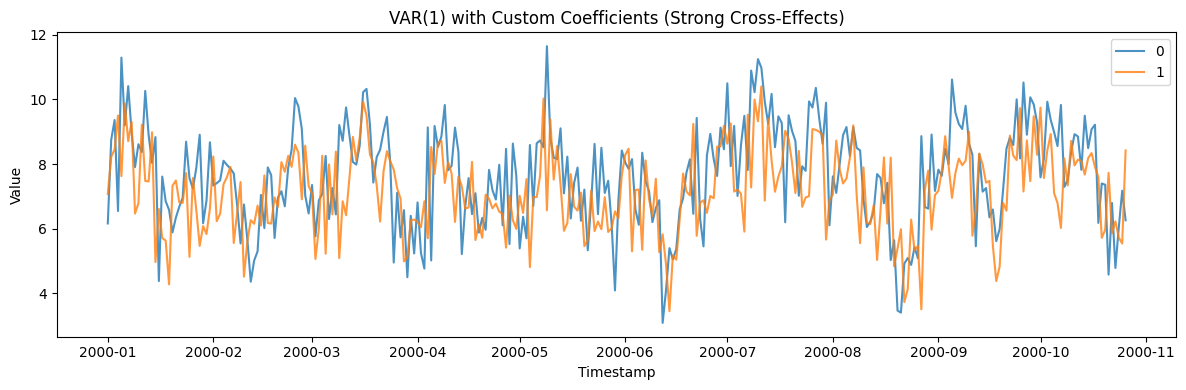

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_custom["unique_id"].unique().to_list():
    series = df_custom.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("VAR(1) with Custom Coefficients (Strong Cross-Effects)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_custom_wide = df_custom.pivot(on="unique_id", index="ds", values="y")
custom_cols = [col for col in df_custom_wide.columns if col != "ds"]
if len(custom_cols) >= 2:
    corr_stocks = np.corrcoef(
        df_custom_wide[custom_cols[0]].to_numpy(),
        df_custom_wide[custom_cols[1]].to_numpy(),
    )[0, 1]
    print(f"Series correlation: {corr_stocks:.3f}")
    print(f"Note: Strong cross-dependencies create correlation between variables")

Series correlation: 0.414
Note: Strong cross-dependencies create correlation between variables


## 3. Higher-Order VAR(3) Model

A VAR(3) model uses three lags of each variable, capturing longer-range dependencies.

In [ ]:
params_var3 = {
    "min_length": 200,
    "max_length": 200,
    "freq": "h",
    "lag_order": 3,
    "seed": 456,
}

gen_var3 = VARGenerator(engine="polars", **params_var3)
df_var3 = gen_var3.generate(n_series=2)

print(f"Generated {len(df_var3)} hourly observations")
print(f"Model: VAR(3) - uses 3 lags of each variable")
df_var3.head(10)

Generated 400 hourly observations
Model: VAR(3) - uses 3 lags of each variable


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-0.221184
"""0""",2000-01-01 01:00:00,-0.122691
"""0""",2000-01-01 02:00:00,0.572251
"""0""",2000-01-01 03:00:00,-2.239382
"""0""",2000-01-01 04:00:00,1.699675
"""0""",2000-01-01 05:00:00,0.831221
"""0""",2000-01-01 06:00:00,0.521463
"""0""",2000-01-01 07:00:00,-0.893806
"""0""",2000-01-01 08:00:00,-0.722153


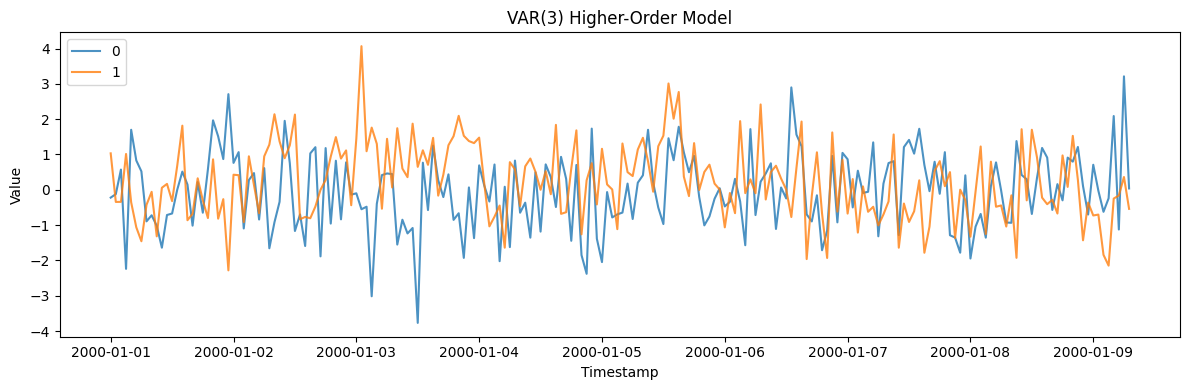

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_var3["unique_id"].unique().to_list():
    series = df_var3.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("VAR(3) Higher-Order Model")
ax.legend()
plt.tight_layout()
plt.show()

## 4. VAR with Correlated Innovations

Specify a custom innovation covariance matrix to add contemporaneous correlation between variables.

In [ ]:
innov_cov = np.array([[1.0, 0.7], [0.7, 1.0]])

params_corr_innov = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "lag_order": 1,
    "innovation_covariance": innov_cov,
    "seed": 789,
}

gen_corr_innov = VARGenerator(engine="polars", **params_corr_innov)
df_corr_innov = gen_corr_innov.generate(n_series=2)

print(f"Generated {len(df_corr_innov)} observations")
print(f"Innovation covariance matrix:\n{innov_cov}")

df_corr_wide = df_corr_innov.pivot(on="unique_id", index="ds", values="y")
corr_cols = [col for col in df_corr_wide.columns if col != "ds"]
if len(corr_cols) >= 2:
    corr_markets = np.corrcoef(
        df_corr_wide[corr_cols[0]].to_numpy(), df_corr_wide[corr_cols[1]].to_numpy()
    )[0, 1]
    print(f"\nSeries correlation: {corr_markets:.3f}")
    print(f"Note: Correlated innovations create additional correlation")

Generated 400 observations
Innovation covariance matrix:
[[1.  0.7]
 [0.7 1. ]]

Series correlation: 0.705
Note: Correlated innovations create additional correlation


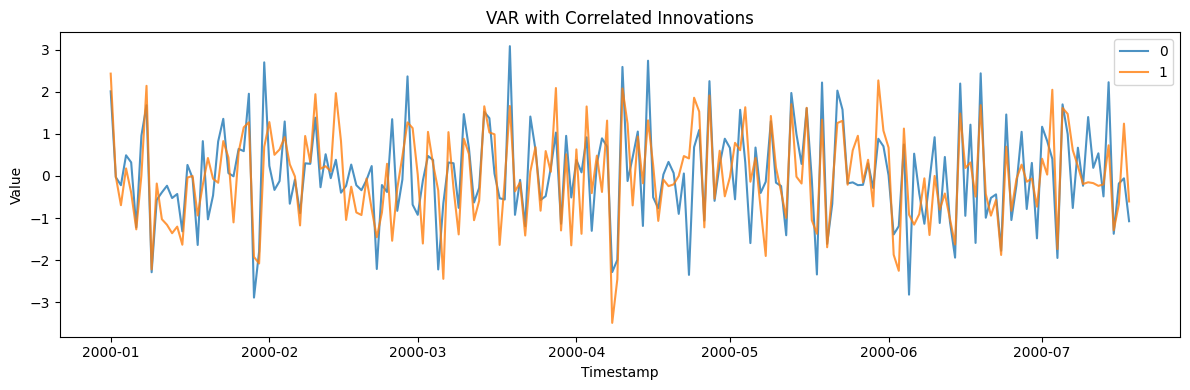

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_corr_innov["unique_id"].unique().to_list():
    series = df_corr_innov.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("VAR with Correlated Innovations")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Generating Multiple VAR Series

Generate multiple independent draws of bivariate VAR series.

In [ ]:
params_multi = {
    "min_length": 100,
    "max_length": 100,
    "freq": "D",
    "lag_order": 1,
    "seed": 999,
}

gen_multi = VARGenerator(engine="polars", **params_multi)
df_multi = gen_multi.generate(n_series=3)

print(f"Generated 3 bivariate VAR series")
print(f"Total rows: {len(df_multi)}")
print(f"Unique series IDs: {df_multi['unique_id'].unique().to_list()}")

df_multi.filter(pl.col("unique_id") == "0").head(5)

Generated 3 bivariate VAR series
Total rows: 300
Unique series IDs: ['0', '1', '2']


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-1.098665
"""0""",2000-01-02 00:00:00,-0.519748
"""0""",2000-01-03 00:00:00,2.138136
"""0""",2000-01-04 00:00:00,-0.6182
"""0""",2000-01-05 00:00:00,-0.871331


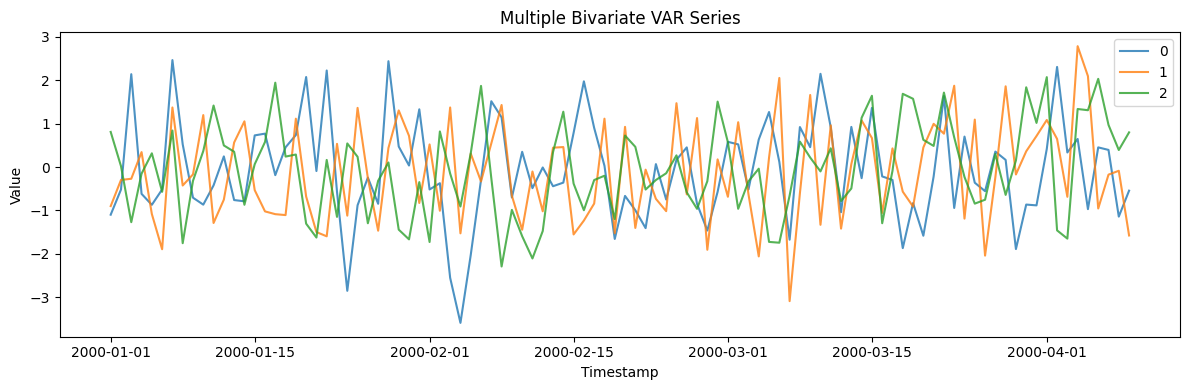

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_multi["unique_id"].unique().to_list():
    series = df_multi.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple Bivariate VAR Series")
ax.legend()
plt.tight_layout()
plt.show()